# 07 — TP2: Regresión de `n_focos`

Predecir el número de focos de incendio (`n_focos`) por hexágono H3 a partir de
8 predictoras ambientales. Se comparan 5 estimadores en **dos formulaciones del
target** —crudo y `log1p`— con todo el preprocesamiento (imputación + escalado
+ one-hot) dentro de un `Pipeline`, y métricas **siempre en la escala original**
de `n_focos`.

Fuente: `data/processed/patagonia_ia.csv` (1981 filas, ya sin el cuadrante de
flaring). No se modifican los scripts `01`–`05`; se reutiliza `src/`.

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd()
proj = RAIZ if (RAIZ / "src").exists() else RAIZ.parent
sys.path.insert(0, str(proj))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, learning_curve
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from src.data import cargar_dataset, preparar_features
from src import modelos as M

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
RSTATE = 42
print("Proyecto:", proj)

Proyecto: C:\Users\juanc\OneDrive\Desktop\PatagonIA\PatagonIA


## 1. Datos y features

`preparar_features` devuelve `X` (7 numéricas + `cobertura_veg` sin encodear) y
el target `n_focos`. Verificamos el único nulo (`elevacion`): **no** se imputa
aquí; la imputación por mediana ocurre dentro del `Pipeline`, tras el split.

In [2]:
df = cargar_dataset(str(proj / "data" / "processed" / "patagonia_ia.csv"))
X, y_cont, _ = preparar_features(df)
y = y_cont.rename("n_focos")

print("X:", X.shape, "| y:", y.shape)
print("Predictoras:", list(X.columns))
print("\nNulos por columna en X:")
print(X.isna().sum()[X.isna().sum() > 0])
print(f"\nn_focos -> min {y.min():.0f} | mediana {y.median():.0f} | "
      f"media {y.mean():.1f} | max {y.max():.0f} | asimetría {y.skew():.2f}")

X: (1981, 8) | y: (1981,)
Predictoras: ['elevacion', 'temp_media', 'precip_anual', 'viento_medio', 'humedad_relativa', 'dist_asentamiento_km', 'dist_ruta_km', 'cobertura_veg']

Nulos por columna en X:
elevacion    1
dtype: int64

n_focos -> min 1 | mediana 8 | media 85.6 | max 2908 | asimetría 5.82


**Nota.** El único faltante es 1 valor de `elevacion`. Imputarlo con la
mediana **antes** del split filtraría información del conjunto completo hacia
test; por eso el `SimpleImputer(strategy="median")` vive dentro del `Pipeline`
(`src/modelos.py`) y aprende la mediana sólo con el fold de entrenamiento.

## 2. Partición

`train_test_split` 80/20 (`random_state=42`) y `KFold(5, shuffle=True,
random_state=42)` sobre train para la validación cruzada de los `GridSearchCV`.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RSTATE)
kf = KFold(n_splits=5, shuffle=True, random_state=RSTATE)

print(f"train: {X_train.shape[0]} filas | test: {X_test.shape[0]} filas")
print(f"n_focos media  train={y_train.mean():.1f}  test={y_test.mean():.1f}")
print(f"n_focos max    train={y_train.max():.0f}  test={y_test.max():.0f}")

train: 1584 filas | test: 397 filas
n_focos media  train=87.3  test=78.8
n_focos max    train=2908  test=1620


## 3. Multicolinealidad — VIF de las 7 predictoras numéricas

El VIF cuantifica cuánto se infla la varianza de cada coeficiente por
correlación con las demás predictoras (regla de bulto: VIF > 5 preocupa, > 10
severo). Motiva el uso de **Ridge**, que regulariza coeficientes correlacionados.

In [4]:
# VIF sobre las numéricas (imputando la mediana sólo para este diagnóstico).
Xn = X[M.NUMERICAS].fillna(X[M.NUMERICAS].median())
Xc = add_constant(Xn)
vif = pd.DataFrame({
    "variable": Xc.columns,
    "VIF": [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])],
})
vif = vif[vif["variable"] != "const"].sort_values("VIF", ascending=False)
print(vif.to_string(index=False))
print("\nCorrelaciones citadas:")
print(f"  precip_anual ↔ humedad_relativa : {Xn['precip_anual'].corr(Xn['humedad_relativa']):.2f}")
print(f"  dist_asentamiento_km ↔ dist_ruta_km : {Xn['dist_asentamiento_km'].corr(Xn['dist_ruta_km']):.2f}")

            variable    VIF
    humedad_relativa 11.749
        precip_anual  9.835
          temp_media  5.856
        viento_medio  3.655
        dist_ruta_km  3.493
dist_asentamiento_km  3.253
           elevacion  2.060

Correlaciones citadas:
  precip_anual ↔ humedad_relativa : 0.82
  dist_asentamiento_km ↔ dist_ruta_km : 0.80


**Lectura VIF.** Las parejas `precip_anual`↔`humedad_relativa` (r≈0.82) y
`dist_asentamiento_km`↔`dist_ruta_km` (r≈0.80) elevan el VIF de esas variables.
Con multicolinealidad, los coeficientes de una regresión lineal ordinaria se
vuelven inestables; **Ridge** (penalización L2) es la respuesta natural y por eso
se incluye con `alpha` elegido por validación cruzada.

## 4. Los 10 modelos (5 estimadores × 2 formulaciones)

Cada estimador se evalúa con `y` crudo y con `y = log1p(y)`. En la formulación
log, el `TransformedTargetRegressor` entrena sobre `log1p(y)`, predice y aplica
`expm1`; las métricas se calculan recién ahí, en la escala original de `n_focos`.

**Hiperparámetros y su justificación:**

- `DummyRegressor(strategy="mean")` — piso: predecir siempre la media.
- `LinearRegression` — baseline sin regularización.
- `Ridge` — `alpha` por `GridSearchCV` sobre `logspace(-2, 4)` (12 valores),
  scoring RMSE, con el `KFold(5)`. Justificado por el VIF de §3.
- `RandomForestRegressor(random_state=42)` — por defecto (100 árboles); captura
  no linealidad e interacciones sin requerir escalado.
- `XGBRegressor(random_state=42)` — boosting; `n_estimators=300`,
  `learning_rate=0.05`, `max_depth=4` como punto de partida conservador para
  limitar sobreajuste en 1584 filas de train.

In [5]:
ALPHAS = np.logspace(-2, 4, 12)

def make_ridge_grid(log1p):
    """Ridge con alpha por GridSearchCV(KFold5), en la formulación pedida."""
    base = M.construir_pipeline(Ridge(random_state=RSTATE), log1p=log1p)
    grid = {M.prefijo_param(log1p) + "alpha": ALPHAS}
    return GridSearchCV(base, grid, cv=kf,
                        scoring="neg_root_mean_squared_error", n_jobs=-1)

def estimadores():
    return {
        "0_Dummy":  DummyRegressor(strategy="mean"),
        "1_Linear": LinearRegression(),
        "3_RF":     RandomForestRegressor(random_state=RSTATE, n_jobs=-1),
        "4_XGB":    XGBRegressor(random_state=RSTATE, n_estimators=300,
                                 learning_rate=0.05, max_depth=4,
                                 n_jobs=-1, verbosity=0),
    }

filas, entrenados = [], {}
for form, log1p in [("crudo", False), ("log1p", True)]:
    # Ridge (GridSearchCV) por separado por su construcción especial
    for nombre, est in estimadores().items():
        pipe = M.construir_pipeline(est, log1p=log1p)
        r = M.evaluar_modelo(pipe, X_train, y_train, X_test, y_test)
        clave = f"{nombre}|{form}"
        entrenados[clave] = r.pop("_modelo")
        filas.append({"modelo": nombre, "formulacion": form, **r})
    # Ridge con grid
    rg = make_ridge_grid(log1p)
    r = M.evaluar_modelo(rg, X_train, y_train, X_test, y_test)
    entrenados[f"2_Ridge|{form}"] = r.pop("_modelo")
    filas.append({"modelo": "2_Ridge", "formulacion": form, **r})

print("Modelos entrenados:", len(filas))
print("Ridge alpha* crudo:",
      entrenados["2_Ridge|crudo"].best_params_)
print("Ridge alpha* log1p:",
      entrenados["2_Ridge|log1p"].best_params_)

Modelos entrenados: 10
Ridge alpha* crudo: {'model__alpha': np.float64(5.336699231206307)}
Ridge alpha* log1p: {'regressor__model__alpha': np.float64(0.01)}


## 5. Tabla comparativa (métricas en escala original, ordenada por RMSE de test)

In [6]:
res = pd.DataFrame(filas)
res = res[["modelo", "formulacion",
           "train_RMSE", "test_RMSE", "train_MAE", "test_MAE",
           "train_MSE", "test_MSE", "train_R2", "test_R2"]]
res = res.sort_values("test_RMSE").reset_index(drop=True)
res.round(3)

,modelo,formulacion,train_RMSE,test_RMSE,train_MAE,test_MAE,train_MSE,test_MSE,train_R2,test_R2
0,4_XGB,crudo,93.468,140.873,46.007,69.143,"8,736.331","19,845.290",0.866,0.391
1,3_RF,log1p,119.874,142.929,31.197,55.801,"14,369.779","20,428.817",0.780,0.373
2,4_XGB,log1p,167.360,156.918,49.653,59.901,"28,009.231","24,623.340",0.571,0.244
3,3_RF,crudo,67.540,161.342,28.274,72.578,"4,561.641","26,031.187",0.930,0.201
4,1_Linear,log1p,245.990,179.333,78.266,71.795,"60,510.980","32,160.415",0.074,0.013
5,2_Ridge,log1p,245.996,179.334,78.267,71.794,"60,513.914","32,160.807",0.074,0.013
6,2_Ridge,crudo,226.979,179.647,111.410,101.886,"51,519.326","32,273.155",0.212,0.010
7,0_Dummy,crudo,255.633,180.706,120.918,107.849,"65,348.455","32,654.655",0.000,-0.002
8,1_Linear,crudo,226.747,182.356,111.379,102.815,"51,414.265","33,253.746",0.213,-0.021
9,0_Dummy,log1p,266.208,192.145,85.064,76.108,"70,866.723","36,919.615",-0.084,-0.133


**Lectura de la tabla.** El `Dummy` fija el piso de RMSE/MAE y da R²≈0 en
test. Comparar `train_*` vs `test_*` por modelo diagnostica sobreajuste: una
brecha grande (train muy por debajo de test) indica que el modelo memoriza. Los
modelos de árbol suelen mostrar `train_R2` alto; lo relevante es el `test_RMSE`.
La formulación `log1p` tiende a reducir el MAE (mejora la mayoría de hexágonos de
pocos focos) aunque puede penalizar el RMSE si subestima la cola de valores altos.

In [7]:
# Diagnóstico explícito de overfitting: brecha train→test
diag = res.copy()
diag["gap_RMSE(test-train)"] = diag["test_RMSE"] - diag["train_RMSE"]
diag["gap_R2(train-test)"] = diag["train_R2"] - diag["test_R2"]
diag[["modelo", "formulacion", "train_RMSE", "test_RMSE",
      "gap_RMSE(test-train)", "train_R2", "test_R2", "gap_R2(train-test)"]].round(3)

,modelo,formulacion,train_RMSE,test_RMSE,gap_RMSE(test-train),train_R2,test_R2,gap_R2(train-test)
0,4_XGB,crudo,93.468,140.873,47.405,0.866,0.391,0.475
1,3_RF,log1p,119.874,142.929,23.055,0.780,0.373,0.407
2,4_XGB,log1p,167.360,156.918,-10.441,0.571,0.244,0.327
3,3_RF,crudo,67.540,161.342,93.802,0.930,0.201,0.729
4,1_Linear,log1p,245.990,179.333,-66.657,0.074,0.013,0.061
5,2_Ridge,log1p,245.996,179.334,-66.661,0.074,0.013,0.061
6,2_Ridge,crudo,226.979,179.647,-47.331,0.212,0.010,0.202
7,0_Dummy,crudo,255.633,180.706,-74.927,0.000,-0.002,0.002
8,1_Linear,crudo,226.747,182.356,-44.391,0.213,-0.021,0.234
9,0_Dummy,log1p,266.208,192.145,-74.063,-0.084,-0.133,0.049


**Diagnóstico de overfitting.** `gap_RMSE` (test−train) y `gap_R2`
(train−test) miden la brecha. Valores pequeños ⇒ el modelo generaliza; brechas
grandes en RF/XGB señalan que convendría regularizar (menor `max_depth`, más
regularización o menos árboles). Los modelos lineales y el Dummy, con baja
capacidad, casi no muestran brecha (poco sesgo de sobreajuste, más de subajuste).

## 6. Visualizaciones

### 6.1 RMSE y MAE por modelo — crudo vs log1p

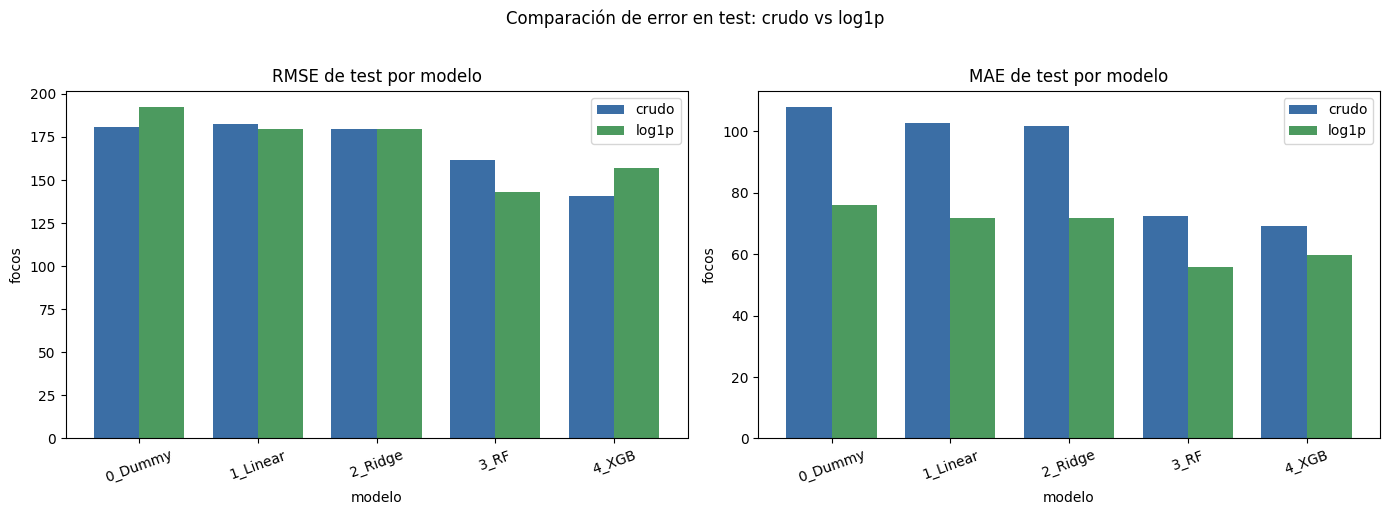

In [8]:
orden = ["0_Dummy", "1_Linear", "2_Ridge", "3_RF", "4_XGB"]
piv_rmse = res.pivot(index="modelo", columns="formulacion", values="test_RMSE").loc[orden]
piv_mae  = res.pivot(index="modelo", columns="formulacion", values="test_MAE").loc[orden]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(orden)); w = 0.38
for ax, piv, titulo in [(axes[0], piv_rmse, "RMSE de test"),
                        (axes[1], piv_mae, "MAE de test")]:
    ax.bar(x - w/2, piv["crudo"], w, label="crudo", color="#3b6ea5")
    ax.bar(x + w/2, piv["log1p"], w, label="log1p", color="#4c9a5f")
    ax.set_xticks(x); ax.set_xticklabels(orden, rotation=20)
    ax.set_title(f"{titulo} por modelo")
    ax.set_ylabel("focos"); ax.set_xlabel("modelo"); ax.legend()
fig.suptitle("Comparación de error en test: crudo vs log1p", y=1.02)
fig.tight_layout(); plt.show()

**Lectura.** Barras agrupadas del error de test. Permite ver de un vistazo
qué estimador gana y si la transformación `log1p` ayuda o perjudica cada métrica.
El contraste RMSE vs MAE es informativo: `log1p` suele bajar el MAE (mediana de
errores) más de lo que baja el RMSE, que está dominado por los pocos hexágonos de
`n_focos` extremos.

### 6.2 Predicho vs real — mejor modelo de cada formulación

Mejor crudo : 4_XGB
Mejor log1p : 3_RF
Mejor global: 4_XGB (crudo), test_RMSE=140.87


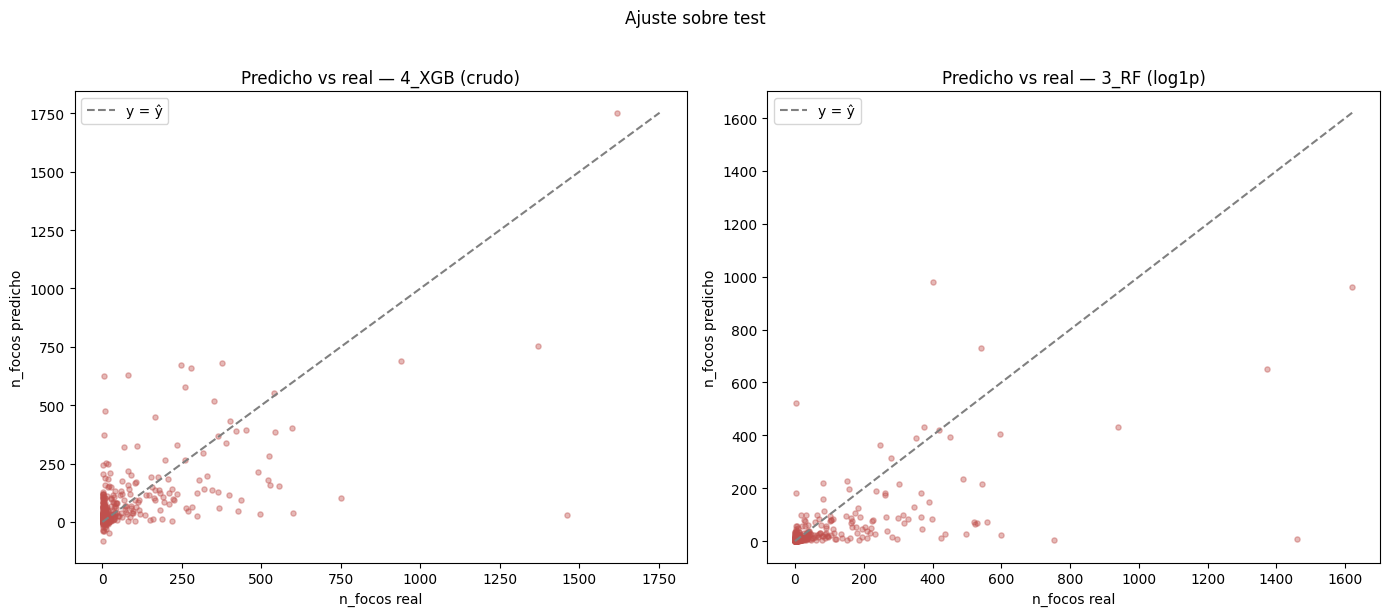

In [9]:
def mejor_de(form):
    sub = res[res.formulacion == form].sort_values("test_RMSE")
    return sub.iloc[0]["modelo"]

mejor_crudo = mejor_de("crudo")
mejor_log = mejor_de("log1p")
mejor_global = res.sort_values("test_RMSE").iloc[0]
print(f"Mejor crudo : {mejor_crudo}")
print(f"Mejor log1p : {mejor_log}")
print(f"Mejor global: {mejor_global['modelo']} ({mejor_global['formulacion']}), "
      f"test_RMSE={mejor_global['test_RMSE']:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (form, nombre) in zip(axes, [("crudo", mejor_crudo), ("log1p", mejor_log)]):
    mdl = entrenados[f"{nombre}|{form}"]
    yp = mdl.predict(X_test)
    ax.scatter(y_test, yp, s=14, alpha=0.4, color="#c0504d")
    lim = [0, max(y_test.max(), yp.max())]
    ax.plot(lim, lim, "--", color="gray", label="y = ŷ")
    ax.set_xlabel("n_focos real"); ax.set_ylabel("n_focos predicho")
    ax.set_title(f"Predicho vs real — {nombre} ({form})")
    ax.legend()
fig.suptitle("Ajuste sobre test", y=1.02)
fig.tight_layout(); plt.show()

**Lectura.** Los puntos deberían alinearse sobre la diagonal `y = ŷ`. La
dispersión creciente hacia la derecha (hexágonos de muchos focos) y la
subestimación sistemática de los valores extremos son típicas de este target de
cola pesada. La formulación `log1p` suele comprimir mejor el rango bajo pero
puede aplanar aún más las predicciones altas.

### 6.3 Residuos vs predicho — heterocedasticidad

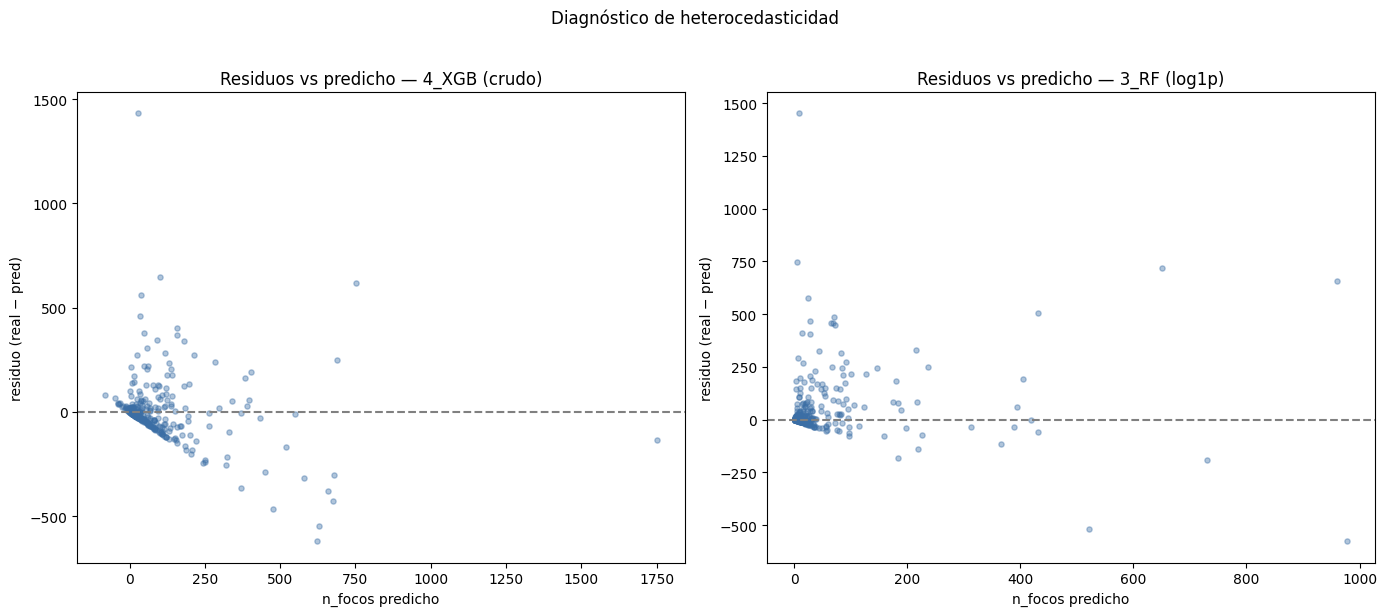

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (form, nombre) in zip(axes, [("crudo", mejor_crudo), ("log1p", mejor_log)]):
    mdl = entrenados[f"{nombre}|{form}"]
    yp = mdl.predict(X_test)
    resid = y_test.values - yp
    ax.scatter(yp, resid, s=14, alpha=0.4, color="#3b6ea5")
    ax.axhline(0, color="gray", ls="--")
    ax.set_xlabel("n_focos predicho"); ax.set_ylabel("residuo (real − pred)")
    ax.set_title(f"Residuos vs predicho — {nombre} ({form})")
fig.suptitle("Diagnóstico de heterocedasticidad", y=1.02)
fig.tight_layout(); plt.show()

**Lectura.** Si la nube de residuos se abre en abanico al crecer la
predicción, hay **heterocedasticidad**: la varianza del error no es constante,
crece con el nivel de focos. Es exactamente lo que motiva la formulación `log1p`,
que estabiliza la varianza. Un patrón sistemático (no centrado en 0) indicaría
además sesgo del modelo en cierto rango.

## 7. Importancia de variables — RF, XGB y coeficientes de Ridge

Se comparan las `feature_importances_` de RF y XGBoost (crudo) con los
coeficientes estandarizados de Ridge (crudo). Los nombres salen del
`OneHotEncoder` del preprocesador.

In [11]:
def nombres_features(pipe_o_ttr):
    prep = (pipe_o_ttr.regressor_.named_steps["prep"]
            if hasattr(pipe_o_ttr, "regressor_")
            else pipe_o_ttr.named_steps["prep"])
    return list(prep.get_feature_names_out())

rf = entrenados["3_RF|crudo"]
xgb = entrenados["4_XGB|crudo"]
ridge = entrenados["2_Ridge|crudo"].best_estimator_

feats = nombres_features(rf)
imp = pd.DataFrame({
    "feature": feats,
    "RF_importance": rf.named_steps["model"].feature_importances_,
    "XGB_importance": xgb.named_steps["model"].feature_importances_,
    "Ridge_coef": ridge.named_steps["model"].coef_,
})
imp["Ridge_coef_abs"] = imp["Ridge_coef"].abs()
imp_sorted = imp.sort_values("RF_importance", ascending=False)
imp_sorted.round(4)

,feature,RF_importance,XGB_importance,Ridge_coef,Ridge_coef_abs
0,num__elevacion,0.194,0.044,10.723,10.723
6,num__dist_ruta_km,0.194,0.033,62.347,62.347
4,num__humedad_relativa,0.148,0.152,95.933,95.933
5,num__dist_asentamiento_km,0.126,0.017,-8.857,8.857
9,cat__cobertura_veg_cultivo,0.102,0.578,376.675,376.675
1,num__temp_media,0.085,0.046,71.717,71.717
2,num__precip_anual,0.065,0.048,-58.978,58.978
3,num__viento_medio,0.058,0.034,-38.365,38.365
13,cat__cobertura_veg_pastizal,0.016,0.023,-29.618,29.618
8,cat__cobertura_veg_bosque,0.008,0.005,-70.368,70.368


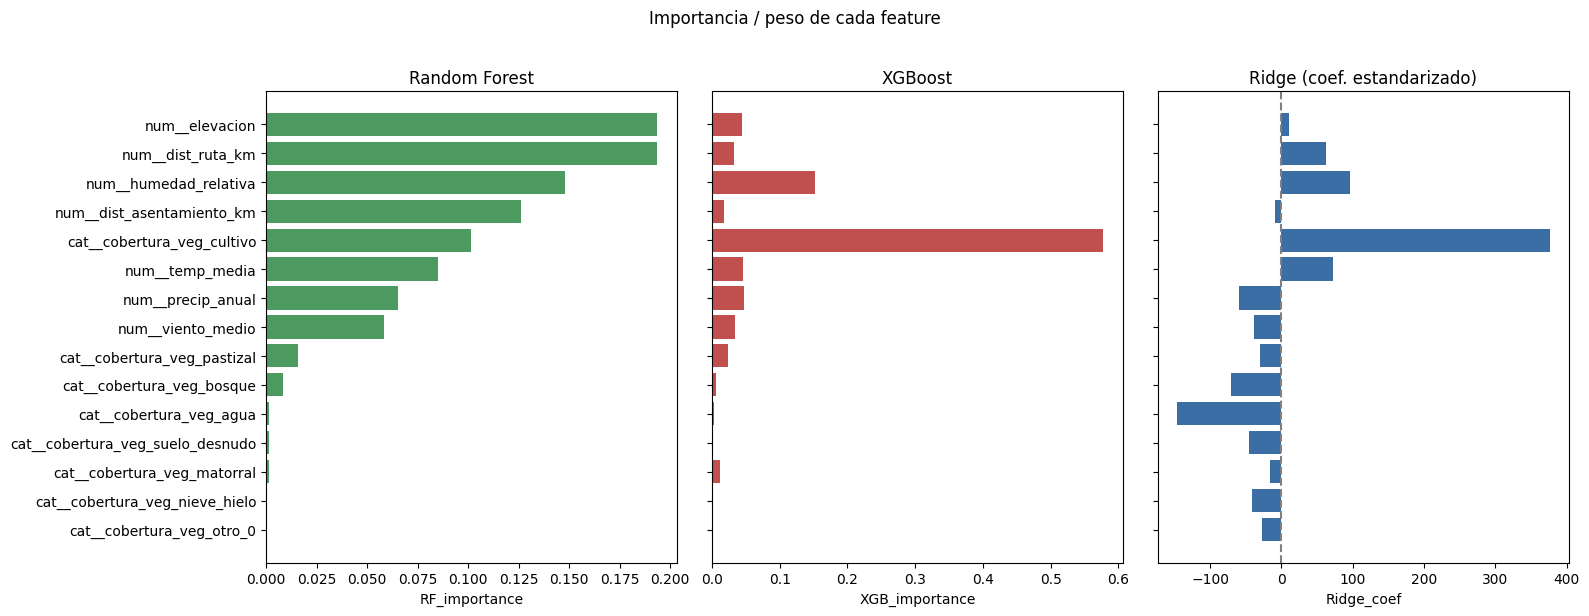

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)
orden_f = imp.sort_values("RF_importance")["feature"]
def barra(ax, col, titulo, color):
    d = imp.set_index("feature").loc[orden_f, col]
    ax.barh(d.index, d.values, color=color)
    ax.set_title(titulo); ax.set_xlabel(col)
barra(axes[0], "RF_importance", "Random Forest", "#4c9a5f")
barra(axes[1], "XGB_importance", "XGBoost", "#c0504d")
barra(axes[2], "Ridge_coef", "Ridge (coef. estandarizado)", "#3b6ea5")
axes[2].axvline(0, color="gray", ls="--")
fig.suptitle("Importancia / peso de cada feature", y=1.02)
fig.tight_layout(); plt.show()

**Lectura.** Árboles y modelo lineal miden cosas distintas:
`feature_importances_` refleja reducción de impureza (magnitud, sin signo),
mientras el coeficiente de Ridge (sobre features estandarizadas) da **dirección
y magnitud** del efecto lineal. Coincidencias entre los tres refuerzan que una
variable es informativa; discrepancias sugieren relaciones no lineales que sólo
los árboles capturan.

## 8. Learning curve del mejor modelo

Curva de aprendizaje (RMSE vs tamaño de train, CV con `KFold(5)`) del mejor
modelo global. Diagnostica si conviene más datos (curvas sin converger) o más
capacidad/menos regularización (brecha train-CV persistente).

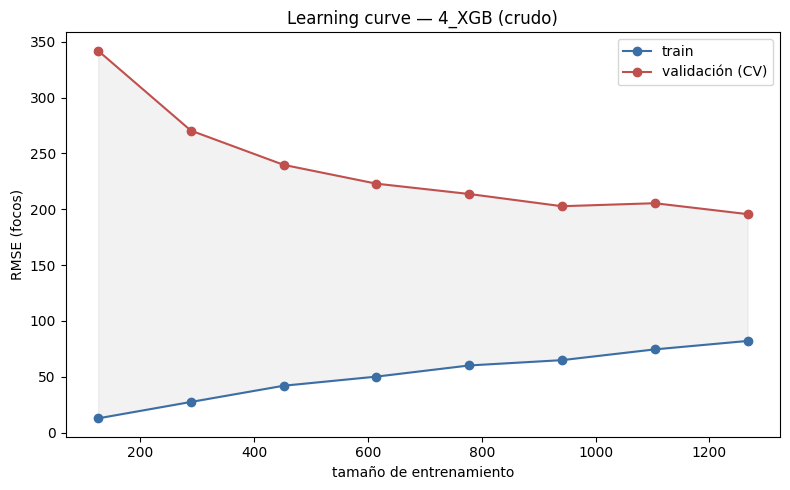

In [13]:
nombre_g = mejor_global["modelo"]; form_g = mejor_global["formulacion"]
mdl_g = entrenados[f"{nombre_g}|{form_g}"]
estimador_lc = mdl_g.best_estimator_ if hasattr(mdl_g, "best_estimator_") else mdl_g

sizes, train_sc, val_sc = learning_curve(
    estimador_lc, X_train, y_train, cv=kf,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1)
train_rmse = -train_sc.mean(axis=1)
val_rmse = -val_sc.mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, train_rmse, "o-", color="#3b6ea5", label="train")
ax.plot(sizes, val_rmse, "o-", color="#c0504d", label="validación (CV)")
ax.fill_between(sizes, train_rmse, val_rmse, alpha=0.1, color="gray")
ax.set_xlabel("tamaño de entrenamiento"); ax.set_ylabel("RMSE (focos)")
ax.set_title(f"Learning curve — {nombre_g} ({form_g})")
ax.legend(); fig.tight_layout(); plt.show()

**Lectura.** Si el RMSE de validación aún desciende al usar todo el train,
más datos ayudarían. Si train y validación quedan separados por una brecha
estable, domina la varianza (sobreajuste): regularizar. Si ambos convergen alto,
domina el sesgo (subajuste): más capacidad o mejores features.

## 9. GridSearchCV — Ridge (alpha) y RF (n_estimators, max_depth)

El de Ridge ya se corrió en §4 (se reportan sus `alpha*`). Aquí se afina RF.
Grilla acotada a propósito para controlar el costo y evitar sobreajustar la
selección: `n_estimators ∈ {200, 400}`, `max_depth ∈ {None, 8, 16}`.

In [14]:
print("Ridge — alpha* seleccionado:")
print("  crudo:", entrenados["2_Ridge|crudo"].best_params_,
      "| log1p:", entrenados["2_Ridge|log1p"].best_params_)

rf_grid = {"model__n_estimators": [200, 400],
           "model__max_depth": [None, 8, 16]}
gs_rf = GridSearchCV(
    M.construir_pipeline(RandomForestRegressor(random_state=RSTATE, n_jobs=-1)),
    rf_grid, cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1)
gs_rf.fit(X_train, y_train)

print("\nRF — mejores hiperparámetros:", gs_rf.best_params_)
print(f"RF — RMSE CV (mejor): {-gs_rf.best_score_:.2f}")
yp_te = gs_rf.predict(X_test)
m_rf_tuned = M.calcular_metricas(y_test, yp_te)
print("RF ajustado — métricas en test:",
      {k: round(v, 3) for k, v in m_rf_tuned.items()})

rf_default_test = res[(res.modelo == "3_RF") & (res.formulacion == "crudo")].iloc[0]
print(f"\nRF por defecto — test_RMSE={rf_default_test['test_RMSE']:.2f} | "
      f"RF ajustado — test_RMSE={m_rf_tuned['RMSE']:.2f}")

Ridge — alpha* seleccionado:
  crudo: {'model__alpha': np.float64(5.336699231206307)} | log1p: {'regressor__model__alpha': np.float64(0.01)}



RF — mejores hiperparámetros: {'model__max_depth': 8, 'model__n_estimators': 400}
RF — RMSE CV (mejor): 184.13
RF ajustado — métricas en test: {'MSE': 25079.204, 'RMSE': 158.364, 'MAE': 72.55, 'R2': 0.23}

RF por defecto — test_RMSE=161.34 | RF ajustado — test_RMSE=158.36


In [15]:
cv_rf = pd.DataFrame(gs_rf.cv_results_)[
    ["param_model__n_estimators", "param_model__max_depth",
     "mean_test_score", "std_test_score", "rank_test_score"]].copy()
cv_rf["mean_RMSE_CV"] = -cv_rf["mean_test_score"]
cv_rf = cv_rf.sort_values("rank_test_score")
cv_rf[["param_model__n_estimators", "param_model__max_depth",
       "mean_RMSE_CV", "std_test_score", "rank_test_score"]].round(3)

,param_model__n_estimators,param_model__max_depth,mean_RMSE_CV,std_test_score,rank_test_score
3,400,8,184.130,30.500,1
2,200,8,184.746,30.554,2
1,400,None,185.850,30.009,3
0,200,None,185.900,30.183,4
5,400,16,186.515,29.693,5
4,200,16,186.590,29.965,6


**Lectura del tuning.** Se contrasta el RF por defecto con el RF ajustado:
si el `test_RMSE` mejora poco, el modelo por defecto ya estaba cerca del óptimo y
la ganancia no justifica el costo. `max_depth` limitado suele reducir la brecha
train-test (menos sobreajuste) a cambio de algo de sesgo; `n_estimators` estabiliza
la predicción con rendimientos decrecientes. La grilla se mantuvo pequeña para no
sobre-optimizar sobre los folds de validación.

## 10. Diagnóstico: ¿por qué `XGB log1p` tiene `train_RMSE` > `test_RMSE`?

Que el error de entrenamiento supere al de test parece contradictorio. La
sospecha razonable es una asimetría en la inversión `expm1`. **No la hay**: el
mismo objeto `TransformedTargetRegressor.predict` aplica `expm1` de forma
idéntica en train y en test (es un único método, sin ramas por partición). La
explicación es la **cola pesada**: el set de train contiene el hexágono extremo
`n_focos = 2908` y muchos más valores altos que el de test; como el RMSE eleva
los residuos al cuadrado, esos pocos extremos —que viven en train— inflan el
`train_RMSE` por encima del `test_RMSE`.

In [16]:
xgb_log = entrenados["4_XGB|log1p"]
print("Tipo:", type(xgb_log).__name__)
print("func      :", xgb_log.func.__name__, "  (aplicado a y antes de entrenar)")
print("inverse_func:", xgb_log.inverse_func.__name__, "  (aplicado a la predicción)")

# Mismo método predict para ambas particiones -> expm1 idéntico:
p_tr = xgb_log.predict(X_train)
p_te = xgb_log.predict(X_test)
print(f"\nmin pred train = {p_tr.min():.3f} | min pred test = {p_te.min():.3f} "
      "(>=0 confirma expm1 aplicado en ambas)")

# ¿De dónde sale el RMSE de train más alto? De la cola que vive en train.
r_tr = np.abs(y_train.values - p_tr)
r_te = np.abs(y_test.values - p_te)
print(f"\nmax |residuo| train = {r_tr.max():.1f}  (en y = {y_train.values[r_tr.argmax()]:.0f})")
print(f"max |residuo| test  = {r_te.max():.1f}  (en y = {y_test.values[r_te.argmax()]:.0f})")
print(f"n(y>500)  train = {int((y_train>500).sum())} | test = {int((y_test>500).sum())}")
print(f"max(y)    train = {y_train.max():.0f} | test = {y_test.max():.0f}")

# Comprobación: sin los extremos, el train_RMSE cae por debajo del test_RMSE.
def rmse(a, b): return float(np.sqrt(((np.asarray(a)-np.asarray(b))**2).mean()))
m = y_train.values <= 500
print(f"\ntrain_RMSE (todo)      = {rmse(y_train, p_tr):.2f}")
print(f"train_RMSE (y<=500)    = {rmse(y_train.values[m], p_tr[m]):.2f}  <- sin la cola, baja fuerte")
print(f"test_RMSE  (todo)      = {rmse(y_test, p_te):.2f}")

Tipo: TransformedTargetRegressor
func      : log1p   (aplicado a y antes de entrenar)
inverse_func: expm1   (aplicado a la predicción)

min pred train = 0.661 | min pred test = 0.917 (>=0 confirma expm1 aplicado en ambas)

max |residuo| train = 2893.0  (en y = 2908)
max |residuo| test  = 1450.6  (en y = 1461)
n(y>500)  train = 67 | test = 13
max(y)    train = 2908 | test = 1620

train_RMSE (todo)      = 167.36
train_RMSE (y<=500)    = 67.62  <- sin la cola, baja fuerte
test_RMSE  (todo)      = 156.92


**Conclusión.** El `train_RMSE > test_RMSE` **no es un error de código ni de
inversión**: es un artefacto del reparto aleatorio de los valores extremos, que
quedaron mayoritariamente en train. Al recortar la cola (`y ≤ 500`), el
`train_RMSE` cae por debajo del `test_RMSE`, restaurando el orden esperado. En
escala `log1p` el modelo optimiza el error logarítmico, donde estos extremos
pesan poco; al volver con `expm1` reaparecen amplificados en el RMSE original.

## 11. Por qué el `Dummy log1p` da R² negativo (media geométrica ≠ aritmética)

El `R² = -0.133` del `Dummy` en formulación `log1p` **no es un fallo**. El
`DummyRegressor(strategy="mean")` predice la media de su target de entrenamiento;
como ese target es `log1p(y)`, su predicción constante es
`mean(log1p(y))`, y tras `expm1` equivale a
`expm1(mean(log1p(y)))` — esto es (salvo el +1) la **media geométrica** de
`n_focos`, no la aritmética.

Con una distribución de cola derecha, la media geométrica es mucho menor que la
aritmética, así que este dummy predice un valor sistemáticamente bajo. El R²
compara contra la media **aritmética** del test; predecir por debajo de ella da
un ajuste peor que el propio promedio ⇒ **R² negativo**. El `Dummy` crudo, que sí
predice la media aritmética, da R² ≈ 0 (el punto de referencia correcto).

In [17]:
dummy_log = entrenados["0_Dummy|log1p"]
pred_cte = dummy_log.predict(X_test)[0]
media_geo = np.expm1(np.log1p(y_train).mean())
media_arit = y_train.mean()
print(f"Predicción constante del Dummy log1p : {pred_cte:.3f}")
print(f"expm1(mean(log1p(y_train)))          : {media_geo:.3f}   <- media geométrica")
print(f"media aritmética de y_train          : {media_arit:.3f}")
print(f"\nEl dummy log1p predice {media_arit/media_geo:.1f}x por debajo de la media aritmética.")

Predicción constante del Dummy log1p : 12.979
expm1(mean(log1p(y_train)))          : 12.979   <- media geométrica
media aritmética de y_train          : 87.265

El dummy log1p predice 6.7x por debajo de la media aritmética.


## 12. Ranking por RMSE vs por MAE — el ganador cambia

RMSE penaliza cuadráticamente los errores grandes (los hexágonos de muchos
focos); MAE los pondera linealmente. Al ser un target de cola pesada, ambos
criterios **no coinciden en el ganador**.

In [18]:
rk = res.copy()
rk["id"] = rk["modelo"] + " (" + rk["formulacion"] + ")"
por_rmse = (rk.sort_values("test_RMSE").reset_index(drop=True)
              [["id", "test_RMSE"]].rename(columns={"id": "modelo_RMSE"}))
por_mae = (rk.sort_values("test_MAE").reset_index(drop=True)
             [["id", "test_MAE"]].rename(columns={"id": "modelo_MAE"}))
ranking = pd.concat([por_rmse, por_mae], axis=1)
ranking.index = ["#" + str(i+1) for i in range(len(ranking))]
print("Ganador por RMSE:", por_rmse.iloc[0]["modelo_RMSE"],
      f"({por_rmse.iloc[0]['test_RMSE']:.2f})")
print("Ganador por MAE :", por_mae.iloc[0]["modelo_MAE"],
      f"({por_mae.iloc[0]['test_MAE']:.2f})")
print("=> El ganador CAMBIA según la métrica.\n")
ranking.round(3)

Ganador por RMSE: 4_XGB (crudo) (140.87)
Ganador por MAE : 3_RF (log1p) (55.80)
=> El ganador CAMBIA según la métrica.



,modelo_RMSE,test_RMSE,modelo_MAE,test_MAE
#1,4_XGB (crudo),140.873,3_RF (log1p),55.801
#2,3_RF (log1p),142.929,4_XGB (log1p),59.901
#3,4_XGB (log1p),156.918,4_XGB (crudo),69.143
#4,3_RF (crudo),161.342,2_Ridge (log1p),71.794
#5,1_Linear (log1p),179.333,1_Linear (log1p),71.795
#6,2_Ridge (log1p),179.334,3_RF (crudo),72.578
#7,2_Ridge (crudo),179.647,0_Dummy (log1p),76.108
#8,0_Dummy (crudo),180.706,2_Ridge (crudo),101.886
#9,1_Linear (crudo),182.356,1_Linear (crudo),102.815
#10,0_Dummy (log1p),192.145,0_Dummy (crudo),107.849


**Lectura.** Por **RMSE** gana `XGB (crudo)`: comete menos errores enormes en
la cola. Por **MAE** gana `RF (log1p)`: acierta mejor en el grueso de hexágonos
de pocos focos, a costa de subestimar los extremos (lo que el RMSE castiga). La
elección de modelo depende, por tanto, del objetivo: minimizar el error típico
(MAE → RF log1p) o acotar los errores catastróficos en zonas de alta actividad
(RMSE → XGB crudo).

## 13. ¿Dónde falla cada uno? MAE por tramo de `n_focos` real

Se descompone el error absoluto medio en test por tramo del valor real
—`0–50`, `50–150`, `150–500`, `>500`— para los dos ganadores: `XGB (crudo)` y
`RF (log1p)`.

In [19]:
bins = [0, 50, 150, 500, np.inf]
labels = ["0-50", "50-150", "150-500", ">500"]
tramo = pd.cut(y_test, bins=bins, labels=labels, right=True, include_lowest=True)

ganadores = {"XGB (crudo)": entrenados["4_XGB|crudo"],
             "RF (log1p)":  entrenados["3_RF|log1p"]}
tabla = pd.DataFrame(index=labels)
tabla["n_hex"] = y_test.groupby(tramo, observed=False).size()
for nombre, mdl in ganadores.items():
    err = np.abs(y_test.values - mdl.predict(X_test))
    tabla[f"MAE {nombre}"] = pd.Series(err, index=y_test.index).groupby(
        tramo, observed=False).mean()
tabla.round(2)

,n_hex,MAE XGB (crudo),MAE RF (log1p)
0-50,291,37.500,11.570
50-150,41,74.890,58.260
150-500,52,155.890,176.410
>500,13,412.390,555.660


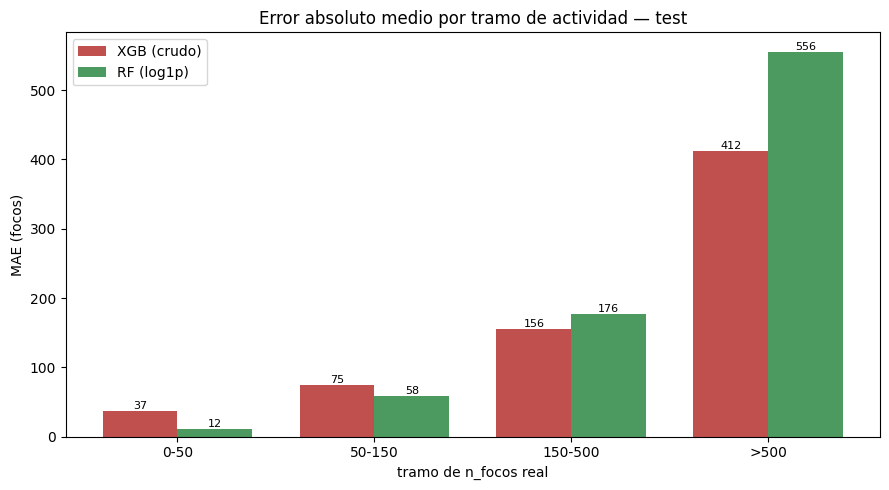

In [20]:
# Visual: MAE por tramo, ambos modelos
fig, ax = plt.subplots(figsize=(9, 5))
xx = np.arange(len(labels)); w = 0.38
ax.bar(xx - w/2, tabla["MAE XGB (crudo)"], w, label="XGB (crudo)", color="#c0504d")
ax.bar(xx + w/2, tabla["MAE RF (log1p)"], w, label="RF (log1p)", color="#4c9a5f")
ax.set_xticks(xx); ax.set_xticklabels(labels)
ax.set_xlabel("tramo de n_focos real"); ax.set_ylabel("MAE (focos)")
ax.set_title("Error absoluto medio por tramo de actividad — test")
ax.legend()
for i, l in enumerate(labels):
    ax.text(i - w/2, tabla["MAE XGB (crudo)"].iloc[i], f"{tabla['MAE XGB (crudo)'].iloc[i]:.0f}",
            ha="center", va="bottom", fontsize=8)
    ax.text(i + w/2, tabla["MAE RF (log1p)"].iloc[i], f"{tabla['MAE RF (log1p)'].iloc[i]:.0f}",
            ha="center", va="bottom", fontsize=8)
fig.tight_layout(); plt.show()

**Lectura.** El patrón esperado: en los tramos bajos (`0–50`, `50–150`),
donde vive la mayoría de los hexágonos, `RF (log1p)` tiene menor MAE — por eso
gana en MAE global. En los tramos altos (`150–500`, `>500`) el error de ambos se
dispara (decenas o cientos de focos), pero `XGB (crudo)` degrada menos en la
cola, lo que explica su ventaja en RMSE. Cada modelo falla donde el otro acierta:
`RF log1p` es preferible para estimar el grueso del territorio; `XGB crudo`, para
no subestimar tanto los focos de alta actividad.

## 14. Síntesis

Se entrenaron 10 modelos (5 estimadores × {crudo, log1p}) con preprocesamiento
encapsulado en `Pipeline` (imputación mediana + escalado + one-hot), partición
80/20 y `KFold(5)`. La tabla de §5 (ordenada por `test_RMSE`), el diagnóstico de
overfitting (§5), las importancias (§7), la learning curve (§8) y el tuning (§9)
son los insumos para responder el cuestionario del TP.